<div style="border:4px solid red">

For all homework blocks that have numerical answers name the variable the hw plus the homework number.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special

# Review

The Sommerfeld diffraction integral is

$E(P_o) = \frac{z}{j\lambda} \int_{\Sigma} E_{inc} \frac{e^{jkr_{01}}}{r_{01}^2} dx' dy'$

The Fresnel diffraction equation is

$E(x,y,z) = \frac{e^{jkz}}{j\lambda z} 
\iint_{\Sigma} E(x',y') 
\exp\left[j\frac{k}{2z}\left((x-x')^2 + (y-y')^2\right)\right]
dx' dy'$

The Fraunhoffer diffraction equation is 

$E(x,y,z) =
\frac{e^{jkz}}{j\lambda z} e^{j\frac{k}{2z}(x^2+y^2)}
\iint_{\Sigma} E(x',y')
\exp\left[-j\frac{k}{z}(xx' + yy')\right] dx' dy'$

$E(x,y,z) = \left( \mathcal{F}_x \{ E(x') \} \right) \left( \mathcal{F}_y \{ E(y') \} \right)$

with $f_x=\frac{x}{\lambda z}$ and $f_y=\frac{y}{\lambda z}$

## Basic Fourier Transform Relations

<details open>
<summary>Click to collapse</summary>

If $f(x) \leftrightarrow F(f)$:

-   $K f(x) \leftrightarrow K F(f)$
-   $f(ax) \leftrightarrow \frac{1}{|a|} F\!\left(\frac{f}{a}\right)$
-   $f(x-x_0) \leftrightarrow F(f)e^{-j2\pi f x_0}$
-   $e^{j2\pi f_0 x} f(x) \leftrightarrow F(f-f_0)$

</details>


## Fourier Transform Pairs
<details open>
<summary>Click to collapse</summary>

| Function | Fourier Transform |
|-----------|------------------|
| $\delta(x)$ | $1$ |
| $A$ | $2\pi A\,\delta(f)$ |
| $\cos(\omega_0 x)$ | $\pi[\delta(f-\omega_0)+\delta(f+\omega_0)]$ |
| $\sin(\omega_0 x)$ | $j\pi[\delta(f-\omega_0)-\delta(f+\omega_0)]$ |
| $\text{rect}(x)$ | $\text{sinc}(f)$ |
| $\Lambda(x)$ | $\text{sinc}^2(f)$ |
| $\text{circ}(r/R)$ | $\pi R^2 \dfrac{J_1(2\pi R f)}{2\pi R f}$ |
| $e^{-\pi x^2}$ | $e^{-\pi f^2}$ |
| $e^{j\pi x^2}$ | $e^{j\pi/4} e^{-j\pi f^2}$ |
| $\sum_{n=-S}^{S}\delta(x-n)$ | $\dfrac{\sin(M\pi f)}{\sin(\pi f)}$, $M=2S+1$ |
| $\sum_{n=-\infty}^{\infty}\delta(x-n)$ | $\sum_{n=-\infty}^{\infty}\delta(f-n)$ |


$\text{rect}(x) = \begin{cases}
1 & |x| \le \frac{1}{2} \\
0 & \text{otherwise}
\end{cases}$

$\text{sinc}(x)=\frac{\sin (\pi x)}{\pi x}$

$\Lambda(x) = \begin{cases}
1-|x| & |x| \le 1 \\
0 & \text{otherwise}
\end{cases}$

$\text{circ}\left(\sqrt{x^2 + y^2}\right) = \begin{cases}
1 & \sqrt{x^2 + y^2} \le 1 \\
0 & \text{otherwise}
\end{cases}$

$\int_{-\infty}^{\infty} \mathrm{sinc}(x)\, dx = 1$

$\int_{-\infty}^{\infty} \mathrm{sinc}^2(x)\, dx = 1$

$\int_{0}^{\infty} \left| \frac{J_1(x)}{x} \right|^2 dx = \frac{4}{3\pi}$

$\int_{0}^{\infty} x \left| \frac{J_1(x)}{x} \right|^2 dx = \frac{1}{2}$

</details>

In [33]:
def lens_aperture_field(x_positions, wavelength, focal_length, distance, aperture_diameter):
    k = 2 * np.pi / wavelength
    half_diameter = aperture_diameter / 2

    # Fresnel propagation phase from the observation plane.
    phase_factor = np.exp(1j * k * x_positions**2 / (2 * distance))

    # Quadratic phase inside the aperture integral after completing the square.
    a = 0.5 * k * (1 / distance - 1 / focal_length)
    b = -k * x_positions / distance

    if np.isclose(a, 0.0):
        # At focus the quadratic term vanishes, so the integral reduces to a sinc-like form.
        aperture_field = np.where(
            np.isclose(b, 0.0),
            aperture_diameter,
            2 * np.sin(b * half_diameter) / b,
        )
    else:
        # Off focus, evaluate the finite-aperture Fresnel integral with Fresnel C/S terms.
        alpha = np.abs(a)
        scale = np.sqrt(2 * alpha / np.pi)
        shift = b / (2 * a)
        u1 = -half_diameter + shift
        u2 = half_diameter + shift
        t1 = scale * u1
        t2 = scale * u2
        c1, s1 = fresnel(t1)
        c2, s2 = fresnel(t2)
        fresnel_sign = 1 if a > 0 else -1
        integral = np.sqrt(np.pi / (2 * alpha)) * (
            (c2 + 1j * fresnel_sign * s2) - (c1 + 1j * fresnel_sign * s1)
        )
        aperture_field = np.exp(-1j * b**2 / (4 * a)) * integral

    return phase_factor * aperture_field

def fwhm_with_bounds(x_positions, values):
    peak_idx = np.argmax(values)
    half_max = 0.5 * values[peak_idx]

    def _interp(x1, y1, x2, y2):
        if y2 == y1:
            return x1
        return x1 + (half_max - y1) * (x2 - x1) / (y2 - y1)

    left = right = None
    for idx in range(peak_idx, 0, -1):
        y_low = values[idx - 1]
        y_high = values[idx]
        if y_low <= half_max <= y_high:
            left = _interp(x_positions[idx - 1], y_low, x_positions[idx], y_high)
            break

    for idx in range(peak_idx, len(values) - 1):
        y_high = values[idx]
        y_low = values[idx + 1]
        if y_high >= half_max >= y_low:
            right = _interp(x_positions[idx], y_high, x_positions[idx + 1], y_low)
            break

    if left is None or right is None:
        return np.nan, np.nan, np.nan

    return right - left, left, right

<div style="border:4px solid red">

**HW1:** A plane wave of intensity $10 mW/cm^2$ and wavelength $\lambda=600 nm$ is incident onto a lens with a focal length of $f=50mm$ and a diameter of $D=10mm$. Plot the 1D normalized diffraction pattern at the plane $z=50mm$. What is the FWHM of the electric field in units of meters?


## Thin Lens Phase Transformation

Lens phase delay

$\phi(x,y) = kn\Delta(x,y) + k(\Delta_0 - \Delta(x,y))$

Lens transmission

$T_{\text{lens}} = \exp(jk\Delta_0) \exp\left(-j\frac{k}{2f}(x^2+y^2)\right)$

The electric field immediately after the lens is given by

$E(x,y) = E_o(x,y) \exp(jk\Delta_0) \exp\left(-j\frac{k}{2f}(x^2+y^2)\right)$

The Fresnel diffraction equation is

$E(x,y,z) = \frac{e^{jkz}}{j\lambda z} 
\iint_{\Sigma} E(x',y') 
\exp\left[j\frac{k}{2z}\left((x-x')^2 + (y-y')^2\right)\right] dx' dy'$

Plug in the electric field immediately after the lens to get

$E(x,y,z) = \frac{e^{jkz}}{j\lambda z} 
\iint_{\Sigma} E_o(x,y) e^{jk \Delta} \exp\left(-j\frac{k}{2f}(x'^2+y'^2)\right)
\exp\left[j\frac{k}{2z}\left((x-x')^2 + (y-y')^2\right)\right] dx' dy'$

Expanding this out we get

$E(x,y,z) = \frac{e^{jk(z+\Delta)}}{j\lambda z} 
\iint_{\Sigma} E_o(x',y')  \exp \left( j\frac{k}{2} \left( -\frac{x'^2}{f} - \frac{y'^2}{f}
+\frac{x'^2}{z}-\frac{2 x \, x'}{z} +\frac{x^2}{z}
+\frac{y'^2}{z}-\frac{2 y \, y'}{z} +\frac{y^2}{z}
\right) \right) dx' dy'$

At the focal plane $z=f$ resulting in the $x'^2$ and $y'^2$ terms canceling resulting in

$E(x,y,z) = \frac{e^{jk(z+\Delta)}}{j\lambda z} 
\iint_{\Sigma} E_o(x',y')  \exp \left( j\frac{k}{2} \left( 
-\frac{2 x \, x'}{f} +\frac{x^2}{f}
-\frac{2 y \, y'}{f} +\frac{y^2}{z}
\right) \right) dx' dy'$

The $x^2$ and $y^2$ terms are independent of the integration parameter resulting in

$E(x,y,z) = \frac{e^{jk(z+\Delta)}}{j\lambda z} 
\exp \left(j \frac{k}{2f} \left( x^2+y^2 \right) \right)
\iint_{\Sigma} E_o(x',y')  
\exp \left( -j\frac{k}{f} \left(x \, x'+ y \, y' \right) \right) dx' dy'$

$E(x,y,z) = \frac{e^{jk(z+\Delta)}}{j\lambda z} 
\exp \left(j \frac{k}{2f} \left( x^2+y^2 \right) \right)
\iint_{\Sigma} E_o(x',y')  
\exp \left( -j\frac{2 \pi}{ \lambda \, f} \left(x \, x'+ y \, y' \right) \right) dx' dy'$

Ignoring the common terms we get 

$E(x,y,z) = \iint_{\Sigma} E_o(x',y')  
\exp \left( -j\frac{2 \pi}{ \lambda \, f} \left(x \, x' \right) \right) dx' \exp \left( -j\frac{2 \pi}{ \lambda \, f} \left(y \, y' \right) \right) dx' dy'$


Thus, at the focus of the lens the diffraction pattern can be solved using Fourier transforms with the relationships of

$f_x = \frac{x}{\lambda f}, \quad f_y = \frac{y}{\lambda f}$

(This is the conversion from the spatial argument to the fourier argument $f$)

hw1 = 3.620046e-06 m
Peak irradiance at focus (for HW2) = 1.111111e+13 W/m^2


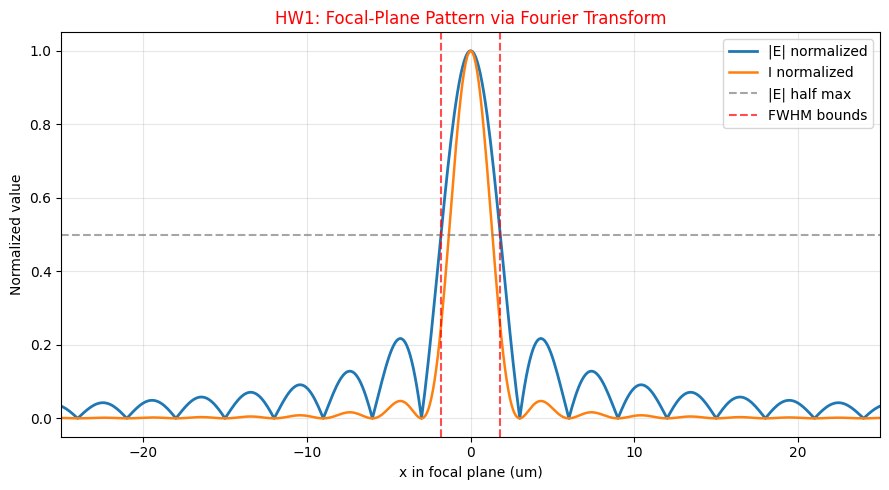

In [34]:
# HW1: Lens focal-plane diffraction using Fourier-transform relationships (real units)
# At z=f, a uniform aperture maps to a sinc field profile in x:
# E(x) = E0 * (D/(lambda*f)) * sinc(D*x/(lambda*f))

# Given parameters
wavelength_hw1 = 600e-9   # m
f_hw1 = 50e-3             # m
D_hw1 = 10e-3             # m
I_in_hw1 = 10e-3 / 1e-4   # 10 mW/cm^2 -> W/m^2 = 100
E0_hw1 = np.sqrt(I_in_hw1)

# Observation coordinate in the focal plane (1D line cut)
x_hw1 = np.linspace(-2.0e-2, 2.0e-2, 400001)  # m

# Fourier-transform result for a 1D top-hat aperture
sinc_arg = (D_hw1 * x_hw1) / (wavelength_hw1 * f_hw1)
E_hw1 = E0_hw1 * (D_hw1 / (wavelength_hw1 * f_hw1)) * np.sinc(sinc_arg)  # sqrt(W/m^2)
I_hw1 = np.abs(E_hw1)**2                                                   # W/m^2

# FWHM of electric field magnitude (prompt asks electric-field FWHM)
E_mag_hw1 = np.abs(E_hw1)
half_E = 0.5 * np.max(E_mag_hw1)
center_idx = np.argmin(np.abs(x_hw1))

left_idx = np.where(E_mag_hw1[:center_idx] <= half_E)[0][-1]
right_idx = center_idx + np.where(E_mag_hw1[center_idx:] <= half_E)[0][0]

x_left = np.interp(half_E, E_mag_hw1[left_idx:center_idx + 1], x_hw1[left_idx:center_idx + 1])
x_right = np.interp(
    half_E,
    E_mag_hw1[center_idx:right_idx + 1][::-1],
    x_hw1[center_idx:right_idx + 1][::-1],
)

hw1 = x_right - x_left
print(f"hw1 = {hw1:.6e} m")

# Normalized shape (for visualizing width)
E_norm_hw1 = E_mag_hw1 / np.max(E_mag_hw1)
I_norm_hw1 = I_hw1 / np.max(I_hw1)

# Real-unit peak irradiance (used by HW2)
I_peak_hw1 = np.max(I_hw1)
print(f"Peak irradiance at focus (for HW2) = {I_peak_hw1:.6e} W/m^2")

plt.figure(figsize=(9, 5))
plt.plot(x_hw1 * 1e6, E_norm_hw1, linewidth=2, label='|E| normalized')
plt.plot(x_hw1 * 1e6, I_norm_hw1, linewidth=1.8, label='I normalized')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='|E| half max')
plt.axvline(x_left * 1e6, color='r', linestyle='--', alpha=0.7)
plt.axvline(x_right * 1e6, color='r', linestyle='--', alpha=0.7, label='FWHM bounds')
plt.xlim(-25, 25)
plt.xlabel('x in focal plane (um)')
plt.ylabel('Normalized value')
plt.title('HW1: Focal-Plane Pattern via Fourier Transform', color='red')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

<div style="border:4px solid red">

**HW2:** A plane wave of intensity $10 mW/cm^2$ and wavelength $\lambda=600 nm$ is incident onto a lens with a focal length of $f=50mm$ and a diameter of $D=10mm$. What is the peak irradiance in units of $\frac{W}{m^2}$?

In [35]:
# HW2: Peak irradiance at focus (circular-aperture Fourier model, real units)

# Given parameters
wavelength_hw2 = 600e-9          # m
f_hw2 = 50e-3                    # m
D_hw2 = 10e-3                    # m
I_in_hw2 = 10e-3 / 1e-4          # 10 mW/cm^2 -> 100 W/m^2

# Circular aperture area
A_hw2 = np.pi * (D_hw2 / 2)**2   # m^2

# On-axis peak irradiance for an ideal circular lens focus
# I_peak = I_in * (A/(lambda*f))^2
hw2 = I_in_hw2 * (A_hw2 / (wavelength_hw2 * f_hw2))**2

print(f"hw2 = {hw2:.6e} W/m^2")

hw2 = 6.853892e+08 W/m^2


<div style="border:4px solid red">

**HW3:** On the web site http://laser.physics.sunysb.edu/~thomas/report1/lens_report.html it explains that a magnifying glass is used to start a fire. About half way down is a set of numbers calculating the irradiance of magnifier 1 with specifications of f=15cm, D=4.7cm, and incident irradiance of $1000 \frac{W}{m^2}$. Calculate the maximum irradiance at the focal plane of the lens in units of $\frac{W}{m^2}$.

In [36]:
# HW3: Magnifier 1 peak irradiance at focal plane (Fourier circular-aperture model)

# Given values
f_hw3 = 0.15          # m (15 cm)
D_hw3 = 0.047         # m (4.7 cm)
I_in_hw3 = 1000.0     # W/m^2

# Using same wavelength convention as prior lens Fourier problems
wavelength_hw3 = 600e-9  # m

# Circular aperture area
A_hw3 = np.pi * (D_hw3 / 2)**2

# Fourier-lens peak irradiance model for a circular pupil
# I_peak = I_in * (A/(lambda*f))^2
hw3 = I_in_hw3 * (A_hw3 / (wavelength_hw3 * f_hw3))**2

print(f"hw3 = {hw3:.6e} W/m^2")

hw3 = 3.716090e+11 W/m^2


<div style="border:4px solid red">

**HW4:** You want create a high irradiance to start a fire.  You want to know if it is better to use a highly corrected lens or a large lens.  Here are the two approaches.  A doublet lens has a focal length of $f1=100mm$ and aperture diameter of $D1=25mm$ (f-number=4).  The other lens is a 100X microscope objective that has a focal length of $f2=2mm$ and diameter of $D2=2mm$ (f-number=1).  What is the FWHM of the irradiance pattern of doublet lens in units of meters?

hw4 = 2.126143e-06 m
(comparison) microscope objective irradiance FWHM = 5.315358e-07 m
FWHM ratio (doublet/microscope) = 4.000


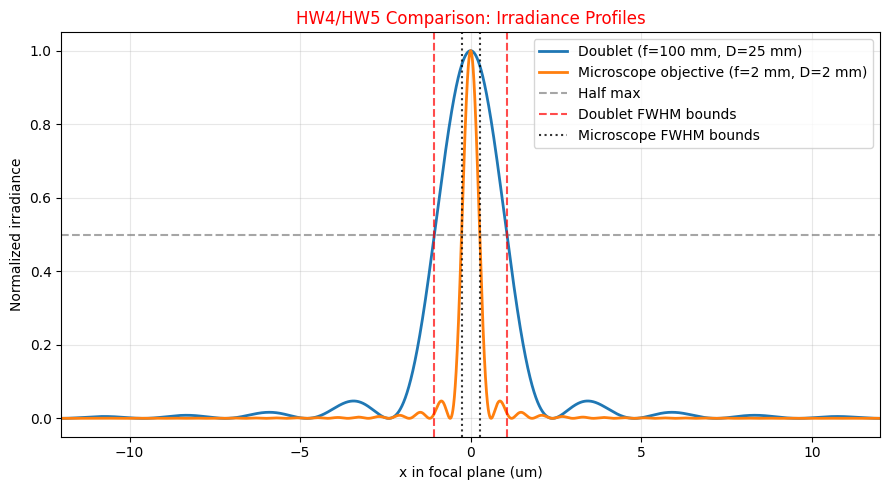

In [37]:
# HW4: FWHM of irradiance pattern for the doublet lens, with comparison to microscope objective

wavelength_hw456 = 600e-9  # m

# Lens set
f1 = 100e-3   # m, doublet focal length
D1 = 25e-3    # m, doublet diameter
f2 = 2e-3     # m, microscope focal length
D2 = 2e-3     # m, microscope diameter


def irradiance_fwhm_sinc2(wavelength, focal_length, diameter, x_span, npts=400001):
    x = np.linspace(-x_span, x_span, npts)
    I_norm = np.sinc((diameter * x) / (wavelength * focal_length))**2

    half = 0.5
    center_idx = np.argmin(np.abs(x))
    left_idx = np.where(I_norm[:center_idx] <= half)[0][-1]
    right_idx = center_idx + np.where(I_norm[center_idx:] <= half)[0][0]

    x_left = np.interp(half, I_norm[left_idx:center_idx + 1], x[left_idx:center_idx + 1])
    x_right = np.interp(
        half,
        I_norm[center_idx:right_idx + 1][::-1],
        x[center_idx:right_idx + 1][::-1],
    )

    return x, I_norm, (x_right - x_left), x_left, x_right


x1, I1_norm, fwhm1, x1_l, x1_r = irradiance_fwhm_sinc2(wavelength_hw456, f1, D1, x_span=60e-6)
x2, I2_norm, fwhm2, x2_l, x2_r = irradiance_fwhm_sinc2(wavelength_hw456, f2, D2, x_span=20e-6)

hw4 = fwhm1

print(f"hw4 = {hw4:.6e} m")
print(f"(comparison) microscope objective irradiance FWHM = {fwhm2:.6e} m")
print(f"FWHM ratio (doublet/microscope) = {fwhm1/fwhm2:.3f}")

plt.figure(figsize=(9, 5))
plt.plot(x1 * 1e6, I1_norm, linewidth=2, label='Doublet (f=100 mm, D=25 mm)')
plt.plot(x2 * 1e6, I2_norm, linewidth=2, label='Microscope objective (f=2 mm, D=2 mm)')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Half max')
plt.axvline(x1_l * 1e6, color='r', linestyle='--', alpha=0.7)
plt.axvline(x1_r * 1e6, color='r', linestyle='--', alpha=0.7, label='Doublet FWHM bounds')
plt.axvline(x2_l * 1e6, color='k', linestyle=':', alpha=0.8)
plt.axvline(x2_r * 1e6, color='k', linestyle=':', alpha=0.8, label='Microscope FWHM bounds')
plt.xlim(-12, 12)
plt.xlabel('x in focal plane (um)')
plt.ylabel('Normalized irradiance')
plt.title('HW4/HW5 Comparison: Irradiance Profiles', color='red')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

<div style="border:4px solid red">

**HW5:** You want create a high irradiance to start a fire.  You want to know if it is better to use a highly corrected lens or a large lens.  Here are the two approaches.  A doublet lens has a focal length of $f1=100mm$ and aperture diameter of $D1=25mm$ (f-number=4).  The other lens is a 100X microscope objective that has a focal length of $f2=2mm$ and diameter of $D2=2mm$ (f-number=1).  What is the FWHM of the irradiance pattern of microscope objective lens in units of meters?

In [38]:
# HW5: FWHM of irradiance pattern for microscope objective

wavelength_hw5 = 600e-9  # m
f2 = 2e-3                # m
D2 = 2e-3                # m

x_hw5 = np.linspace(-20e-6, 20e-6, 300001)
I_hw5_norm = np.sinc((D2 * x_hw5) / (wavelength_hw5 * f2))**2

half = 0.5
center_idx = np.argmin(np.abs(x_hw5))
left_idx = np.where(I_hw5_norm[:center_idx] <= half)[0][-1]
right_idx = center_idx + np.where(I_hw5_norm[center_idx:] <= half)[0][0]

x_left = np.interp(half, I_hw5_norm[left_idx:center_idx + 1], x_hw5[left_idx:center_idx + 1])
x_right = np.interp(
    half,
    I_hw5_norm[center_idx:right_idx + 1][::-1],
    x_hw5[center_idx:right_idx + 1][::-1],
)

hw5 = x_right - x_left

print(f"hw5 = {hw5:.6e} m")

hw5 = 5.315358e-07 m


<div style="border:4px solid red">

**HW6:** You want create a high irradiance to start a fire.  You want to know if it is better to use a highly corrected lens or a large lens.  Here are the two approaches.  A doublet lens has a focal length of $f1=100mm$ and aperture diameter of $D1=25mm$ (f-number=4).  The other lens is a 100X microscope objective that has a focal length of $f2=2mm$ and diameter of $D2=2mm$ (f-number=1).  The surface irradiance is $1000 \frac{W}{m^2}$.  What is the peak irradiance of the doublet lens in units of $\frac{W}{m^2}$?

In [39]:
# HW6: Peak irradiance comparison for doublet vs microscope objective (surface irradiance = 1000 W/m^2)

wavelength_hw6 = 600e-9  # m
I_surface = 1000.0       # W/m^2

# Doublet lens
f1 = 100e-3
D1 = 25e-3
A1 = np.pi * (D1 / 2)**2

# Microscope objective (comparison)
f2 = 2e-3
D2 = 2e-3
A2 = np.pi * (D2 / 2)**2

# Circular-aperture Fourier model: I_peak = I_in * (A/(lambda*f))^2
I_peak_doublet = I_surface * (A1 / (wavelength_hw6 * f1))**2
I_peak_micro = I_surface * (A2 / (wavelength_hw6 * f2))**2

hw6 = I_peak_doublet

print(f"hw6 = {hw6:.6e} W/m^2  (doublet peak irradiance)")
print(f"Microscope objective peak irradiance = {I_peak_micro:.6e} W/m^2")
print(f"Irradiance ratio (doublet/microscope) = {I_peak_doublet / I_peak_micro:.3f}")

hw6 = 6.693254e+10 W/m^2  (doublet peak irradiance)
Microscope objective peak irradiance = 6.853892e+09 W/m^2
Irradiance ratio (doublet/microscope) = 9.766


<div style="border:4px solid red">

**HW7:** The electric field at the $z=0$ plane is given by 
$E(x,y)=0.2e^{-j0.8 \times 10^7x}$ and the wavelength is $\lambda=500 nm$.  What is the magnitude of the angle between the $z$-axis and the propagation angle of the plane wave in units of degrees?   

In [40]:
k_x = 0.8e7 # k_x = spatial frequency along x direction

lam = 500e-9
k = 2 * np.pi / lam

theta = np.arcsin(k_x / k)
print(f"theta = {np.rad2deg(theta):.3f} degrees")

theta = 39.540 degrees


<div style="border:4px solid red">

**HW8:** At the $z=0$ plane there is a lens with an aperture that has a diameter of $D=5mm$ and a focal length of $f=50mm$.  The irradiance is measured at the $z=50mm$ plane. What is the distance in meters between the point $(x=0, y=0, z=0.05)$ and the point where the irradiance is a maximum?  The point is in units of meters.

In [41]:
# HW8: Distance from optical axis point to peak-irradiance point at the focal plane

# Use the plane-wave tilt from HW7: E ~ exp(-j*kx*x)
kx_hw8 = 0.8e7          # rad/m
wavelength_hw8 = 500e-9 # m
f_hw8 = 50e-3           # m

k_hw8 = 2 * np.pi / wavelength_hw8
sin_theta = kx_hw8 / k_hw8

if np.abs(sin_theta) > 1:
    raise ValueError("Invalid plane-wave tilt: |kx/k| > 1")

# Fourier shift relation for lens focal plane:
# x_peak = f * sin(theta) = f * (kx/k)
x_peak = f_hw8 * sin_theta

# Requested distance from (0,0,0.05) to the peak point in the z=0.05 plane
# Peak is at (x_peak, 0, 0.05), so distance is |x_peak|
hw8 = np.abs(x_peak)

print(f"sin(theta) = {sin_theta:.6f}")
print(f"x_peak at z=f = {x_peak:.6e} m")
print(f"hw8 = {hw8:.6e} m")

sin(theta) = 0.636620
x_peak at z=f = 3.183099e-02 m
hw8 = 3.183099e-02 m


<div style="border:4px solid red">

**HW9:** An LED with a wavelength of $\lambda=515nm$ is approximated as a point source with an luminous intensity of $70 cd$.  The LED is $3m$ away from your eye.  What is the peak irradiance on your retina in units of $\frac{lm}{m^2}$?  Treat the eye as an ideal lens with focal length of $f=17mm$ and the pupil has a diameter of $3mm$.

In [42]:
# HW9: Peak retinal illuminance (lm/m^2) for a point-source LED imaged by the eye

# Given
I_led = 70.0           # cd = lm/sr
r_led_eye = 3.0        # m
wavelength_hw9 = 515e-9  # m
f_eye = 17e-3          # m
D_pupil = 3e-3         # m

# Illuminance at the pupil from a point source
# E_pupil = I / r^2  (lux = lm/m^2)
E_pupil = I_led / (r_led_eye**2)

# Circular pupil area
A_pupil = np.pi * (D_pupil / 2)**2

# Fourier circular-aperture peak scaling in photometric units
# E_peak_retina = E_pupil * (A/(lambda*f))^2
hw9 = E_pupil * (A_pupil / (wavelength_hw9 * f_eye))**2

print(f"Pupil illuminance = {E_pupil:.6e} lm/m^2")
print(f"hw9 = {hw9:.6e} lm/m^2")

Pupil illuminance = 7.777778e+00 lm/m^2
hw9 = 5.070001e+06 lm/m^2
